# Analysis notebook for Datasets

This notebook aims to preprocess and analyze the dataset acquired during random navigation in the Tmaze environment

As result, this notebook curates the CSV file where the data is stored and the pictures related to it.

This curating process includes:
* Removal of timesteps and images recorded after reward.
* Removal of timesteps and images in stuck period of non-rewarded trials.
* Removal of images with no related metrics in the CSV file
* Analysis of agent trajectories and spatial occupancy.
* Count of rewards gathered.

## Import libraries

In [1]:
import matplotlib.pyplot as plt
import scipy.stats as sci
import statistics as stt
import pandas as pd
import numpy as np
import pathlib
import ast
import csv
import os

## Import data

In [78]:
dataset_version = 3

repo_path = str(pathlib.Path().resolve().parents[0])
plot_folder = repo_path + "/Plots/Tmaze_old" + str(dataset_version) + "/"

dataset_path = repo_path + "/Datasets/Tmaze_old" + str(dataset_version) + "/"
csv_filename = dataset_path + "data.csv"
print(dataset_path)

C:\Users\specs\Desktop\Robotology\Repos\HPC-VTA_Autoencoder/Datasets/Tmaze_old3/


In [80]:
print(len([name for name in os.listdir(dataset_path) if os.path.isfile(os.path.join(dataset_path, name))]))

40001


In [81]:
Tmaze_data = pd.read_csv(csv_filename)
Tmaze_data['Row_index'] = Tmaze_data.index
print('Tmaze Number of columns = ' + str(Tmaze_data.shape[1]))
print('Tmaze Number of rows = ' + str(Tmaze_data.shape[0]))
Tmaze_data

Tmaze Number of columns = 14
Tmaze Number of rows = 39998


,Trial_number,Trial_time,Frame_ID,Embedding,action,retrieved_action,X,Y,Z,Internal_states,RewardID,Reward_value,n_replays,Row_index
0,0,1.024,1,[],"[0, 0]",False,-0.000008,-0.509500,270.045416,"[0.499, 0.999]",0,"[0, 0, 0, 0]",0,0
1,0,2.048,2,[],"[6.28, 6.28]",False,0.000089,-0.388893,270.045456,"[0.498, 0.998]",0,"[0, 0, 0, 0]",0,1
2,0,3.072,3,[],"[-0.79, 0.79]",False,-0.005057,-0.383420,302.613868,"[0.497, 0.997]",0,"[0, 0, 0, 0]",0,2
3,0,4.096,4,[],"[4.71, 6.28]",False,0.069157,-0.308481,332.811220,"[0.496, 0.996]",0,"[0, 0, 0, 0]",0,3
4,0,5.120,5,[],"[3.14, 1.57]",False,0.109097,-0.281132,303.218589,"[0.495, 0.995]",0,"[0, 0, 0, 0]",0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39993,62,387.072,39996,[],"[3.93, 4.71]",False,-0.439731,0.516282,149.538959,"[0.622, 0.122]",0,"[0, 0, 0, 0]",0,39993
39994,62,388.096,39997,[],"[0.0, 1.57]",False,-0.455805,0.506095,181.299119,"[0.621, 0.121]",0,"[0, 0, 0, 0]",0,39994
39995,62,389.120,39998,[],"[3.93, 4.71]",False,-0.538149,0.517654,197.531317,"[0.62, 0.12]",0,"[0, 0, 0, 0]",0,39995
39996,62,390.144,39999,[],"[0.79, -0.79]",False,-0.540622,0.523531,167.295763,"[0.619, 0.119]",0,"[0, 0, 0, 0]",0,39996


In [82]:
Tmaze_Total_trials = len(np.unique(Tmaze_data['Trial_number']))
print('Tmaze Total trials = ' + str(Tmaze_Total_trials))

Tmaze Total trials = 63


In [83]:
Tmaze_frame_ids = list(Tmaze_data['Frame_ID'])

a=1
missing_frames=[]
for u in range(len(Tmaze_frame_ids)):
    if Tmaze_frame_ids[u] != a:
        missing_frames.append(a)
        a += 1
    a+= 1
print('Total missing frames in dataset: ' + str(len(missing_frames)))
print('Missing frames in dataset: ' + str(missing_frames))

Total missing frames in dataset: 2
Missing frames in dataset: [11494, 38012]


Images not considered in the CSV file must be removed. \
It is done in the **clean picture dataset** section

## Pre Plotting

In [86]:
Tmaze_exp_time = Tmaze_data['Trial_time'][Tmaze_data.shape[0]-1]
Tmaze_n_frames = Tmaze_data['Frame_ID'][Tmaze_data.shape[0]-1]
print('Tmaze Experiment duration = ', Tmaze_exp_time, 'secs')
print('Tmaze Action/frame rate =', (round(Tmaze_exp_time/Tmaze_n_frames, 3)), 'per sec.')

Tmaze Experiment duration =  391.168 secs
Tmaze Action/frame rate = 0.01 per sec.


In [87]:
# Save  full data into lists
Tmaze_Xpose = Tmaze_data['X'].to_list()
Tmaze_Ypose = Tmaze_data['Y'].to_list()

In [88]:
def occupancy_map(filename, Xpose, Ypose, plot_folder, save=False):
    xy_array = np.column_stack((Xpose, Ypose))
    x_array = xy_array[:, 0]
    y_array = xy_array[:, 1]

    x_bins = 150  # Fewer bins for the X-axis
    y_bins = 150  # Keeping more bins for the Y-axis to maintain aspect ratio
    figsize=(7, 6)
    if filename == 'LinearTrack':
        x_bins = 15
        figsize=(2, 6)

    xedges = np.linspace(min(Xpose), max(Xpose), x_bins + 1)
    yedges = np.linspace(min(Ypose), max(Ypose), y_bins + 1)

    fig, ax = plt.subplots(figsize=figsize)  # Adjusting the figure size for better aspect ratio
    ax.set_aspect("auto")

    hist, xedges, yedges, im = ax.hist2d(x_array, y_array, bins=[xedges, yedges])
    H = hist.T
    H_normalized = H / float(xy_array.shape[0])

    ax.set_title(filename + ' occupancy map', fontsize=15)
    ax.set_yticks(np.arange(min(Ypose), max(Ypose), step=.25))
    ax.set_xticks(np.arange(min(Xpose), max(Xpose), step=.5))

    hist_im = ax.imshow(H_normalized, origin='lower', extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], aspect='auto')
    cbar = fig.colorbar(hist_im)
    cbar.set_label('Normal timesteps', rotation=270, fontsize=15, labelpad=+25)

    plt.show()

    if save:
        fig.savefig(plot_folder + '/Occupancy_map.pdf', format='pdf', bbox_inches='tight')
        fig.savefig(plot_folder + '/Occupancy_map.png', format='png')

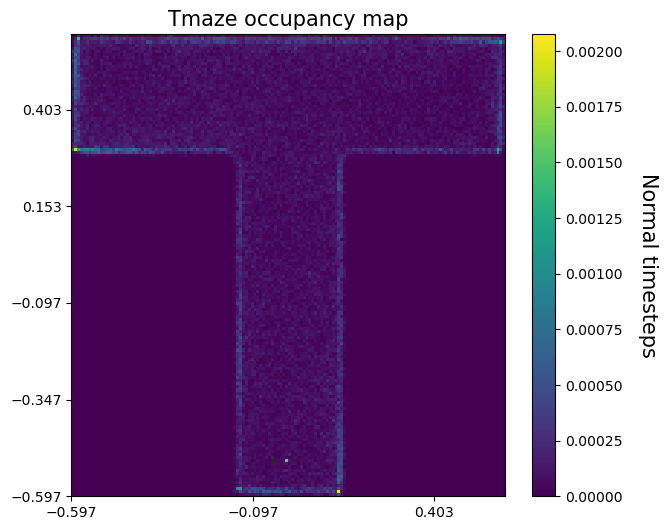

In [89]:
occupancy_map('Tmaze', Tmaze_Xpose, Tmaze_Ypose, plot_folder, save=False)

In [91]:
def agent_trajectory(filename, Xpose, Ypose, plot_folder, save=False):
    if filename == 'OpenArena':
        obstacle1x = [-1.22, -1.22, 1.22, 1.22, -1.22]
        obstacle1y = [1.22, -1.22, -1.22, 1.22, 1.22]
        obstaclesx = [obstacle1x]
        obstaclesy = [obstacle1y]
        
    if filename == 'LinearTrack':
        obstacle1x = [-.22, -.22, .22, .22, -.22]
        obstacle1y = [1.22, -1.22, -1.22, 1.22, 1.22]
        obstaclesx = [obstacle1x]
        obstaclesy = [obstacle1y]
        
    if filename == 'Tmaze':
        obstacle1x = [-0.15, -0.15, -0.6, -0.6, 0.6, 0.6, 0.16, 0.16, -0.15]
        obstacle1y = [-0.60, 0.28, 0.28, 0.60, 0.60, 0.28, 0.28, -0.60, -0.60]
        obstaclesx = [obstacle1x]
        obstaclesy = [obstacle1y]
        
    if filename == 'DoubleTmaze':
        obstacle1x =[-1.22, -1.22, -.45, -.45, -1.1, -1.1, -.45, -.45, -1.22, -1.22, -.07, -.07, .07, .07, 1.22, 1.22, .45,
                    .45, 1.1, 1.1, .45, .45, 1.22, 1.22, .07, .07, -.07, -.07, -1.22]
        obstacle1y =[-1.2, -.8, -.8, -.7, -.7, .7, .7, .8, .8, 1.2, 1.2, .75, .75, 1.2, 1.2, .8, .8, .7, .7, -.7, -.7, 
                    -.8, -.8, -1.2, -1.2, -.75, -.75, -1.2, -1.2]
        obstacle2x = [-.4, -.4, .4, .4, -.4]
        obstacle2y = [-.35, -.2, -.2, -.35, -.35]
        obstacle3x = [-.4, -.4, .4, .4, -.4]
        obstacle3y = [.35, .2, .2, .35, .35]
        obstaclesx = [obstacle1x, obstacle2x,obstacle3x]
        obstaclesy = [obstacle1y, obstacle2y,obstacle3y]

    figsize=(10,10)
    if filename == 'LinearTrack':
        figsize=(3,10)
        
    fig = plt.figure(figsize=figsize)

    for i in range(len(obstaclesx)):
        plt.plot(obstaclesx[i], obstaclesy[i], linewidth=3, color='grey')

    plt.plot(Xpose, Ypose, linewidth=0.5)
    plt.yticks(np.arange(-2, 2, step=.2), fontsize=10)
    plt.xticks(np.arange(-2, 2, step=.2), fontsize=10)
    plt.title(filename + " agent's trajectory", fontsize=30)
    plt.plot(Xpose[0],Ypose[0],'ro', markersize=10)
    plt.show()
    
    if save:
        fig.savefig(plot_folder + '/Trajectory.pdf', format='pdf', bbox_inches='tight')
        fig.savefig(plot_folder + '/Trajectory.png', format='png')

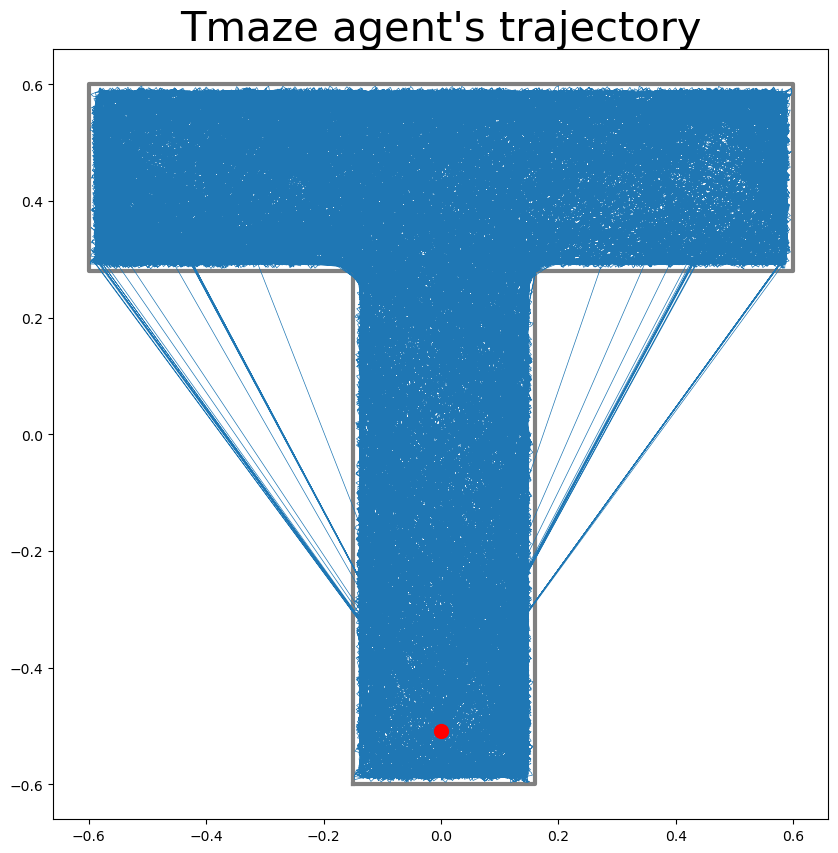

In [98]:
agent_trajectory('Tmaze', Tmaze_Xpose, Tmaze_Ypose, plot_folder, save=False)

In [102]:
def delete_image(path, missing_frames):
    for i in range(len(missing_frames)):
        filename = str(missing_frames[i])
        while len(filename) < 5:
            filename = "0" + filename
        image_path = path + filename + ".jpg"

        if os.path.exists(image_path):
            os.remove(image_path)
        else:
            print(f"File not found: {image_path}")

In [105]:
delete_image(dataset_path, missing_frames)